# Coupling Methods

In flow matching, a **coupling** decides which source point gets paired with which target point inside each batch.

This notebook covers two coupling strategies:

| Coupling | Strategy | Cost |
|---|---|---|
| `independent_coupling` | Uniform random pairing | O(N) |
| `ot_linear_coupling` | Minimise total transport cost (Sinkhorn) | O(N² log N) |

All return the same: `(src_idx, tgt_idx)` — index arrays used to reorder the batch before the training step.

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd

from sc_flow.backends.torch.coupling import independent_coupling, ot_linear_coupling
from sc_flow.dataset.toy_data import get_toy_dataset
from sc_flow import SCFlow

torch.manual_seed(42)
np.random.seed(42)

## Data

We load two datasets:

- **`moon_all`** — Target
- **`gauss_clusters`** — Source

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

# ── Moons (target) ────────────────────────────────────────────────────────────
adata = get_toy_dataset("moons", n_samples=1000, noise=0.05, random_state=42).adata
moon_all = torch.tensor(np.array(adata.X, dtype=np.float32))

# ── Gaussian clusters (source) ────────────────────────────────────────────────
n_clusters = 8
ring_radius = 2.5
moon_center = np.array([0.5, 0.05])
angles = np.linspace(0, 2 * np.pi, n_clusters, endpoint=False)
centers = moon_center + ring_radius * np.column_stack([np.cos(angles), np.sin(angles)])
gauss_clusters = torch.tensor(np.vstack([np.random.randn(60, 2) * 0.18 + c for c in centers]).astype(np.float32))

# ── Small batch for coupling plots ────────────────────────────────────────────
N = 100
src = gauss_clusters[torch.randperm(len(gauss_clusters))[:N]]
tgt = moon_all[torch.randperm(len(moon_all))[:N]]

print(f"gauss_clusters : {gauss_clusters.shape}  (source)")
print(f"moon_all       : {moon_all.shape}  (target)")


def plot_pairs(ax, src, tgt, src_idx, tgt_idx, title, color="gray", alpha=0.6):
    """Plot pairs of points between source and target."""
    for i in range(len(src_idx)):
        s = src[src_idx[i]].numpy()
        t = tgt[tgt_idx[i]].numpy()
        ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.9, alpha=alpha, color=color)
    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="Moons")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="Gauss clusters"
    )
    ax.set_title(title, fontsize=11, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

gauss_clusters : torch.Size([480, 2])  (source)
moon_all       : torch.Size([1000, 2])  (target)


---
## 1. Independent Coupling

Two independent random permutations are drawn and paired by position — no matrix is computed, no geometry is used. Every (source, target) pair has equal probability 1/N².

In [21]:
src_idx, tgt_idx = independent_coupling(src, tgt)

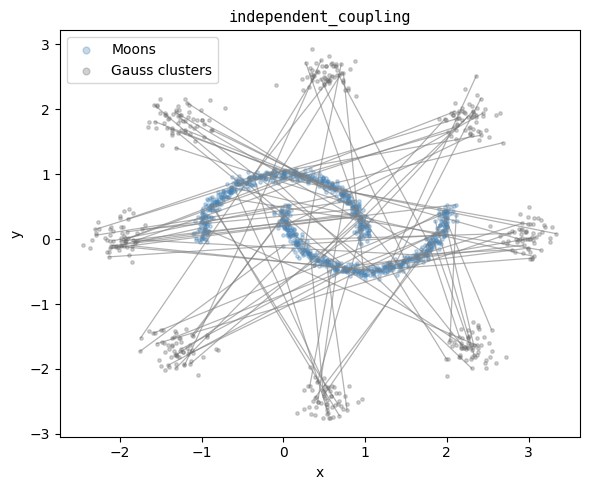

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_pairs(ax, src, tgt, src_idx, tgt_idx, title="independent_coupling")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
## 2. OT Linear Coupling

OT linear coupling solves an optimal transport problem: find a plan T (an N×M matrix) that minimises the total cost of moving mass from source to target, where cost defaults to squared Euclidean distance. T[i,j] represents how much probability mass flows from source i to target j.

| `method` | Effect |
|---|---|
| `"exact"` | Earth mover's distance |
| `"sinkhorn"` | Entropic regularisation (default) |
| `"partial"` | Only a fraction `m` of total mass is transported |
| `"unbalanced"` | Relaxed marginals |

In [ ]:
src_idx, tgt_idx = ot_linear_coupling(src, tgt)
# src_idx_mat, tgt_idx_mat, tmat = ot_linear_coupling(src, tgt, return_matrix=True, reg=0.01)

print(f"src_idx shape  : {src_idx.shape}")
print(f"tgt_idx shape  : {tgt_idx.shape}")
# print(f"coupling matrix: {tmat.shape}")

src_idx shape  : (100,)
tgt_idx shape  : (100,)
coupling matrix: (100, 100)


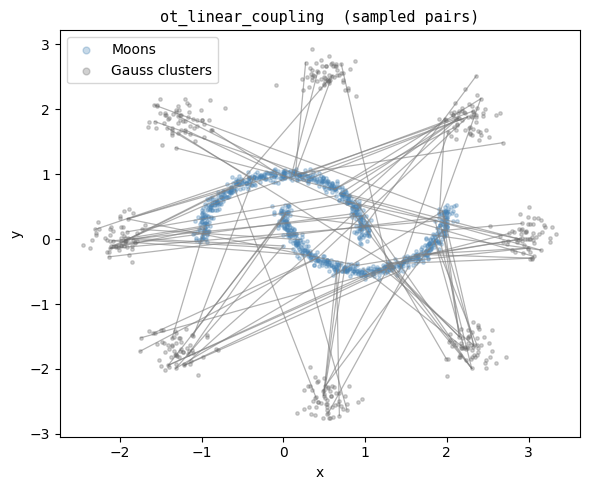

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_pairs(ax, src, tgt, src_idx, tgt_idx, title="ot_linear_coupling  (sampled pairs)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

### Effect of `reg`

`reg` controls the entropy of the transport plan. A low `reg` produces a sharp, near-deterministic plan. A high `reg` produces a diffuse plan — each source spreads its mass across many targets.

In [25]:
regs = [0.01, 0.1, 0.5]

coupling_matrices_reg = {}
for reg in regs:
    _, _, tmat = ot_linear_coupling(src, tgt, return_matrix=True, reg=reg)
    coupling_matrices_reg[reg] = tmat

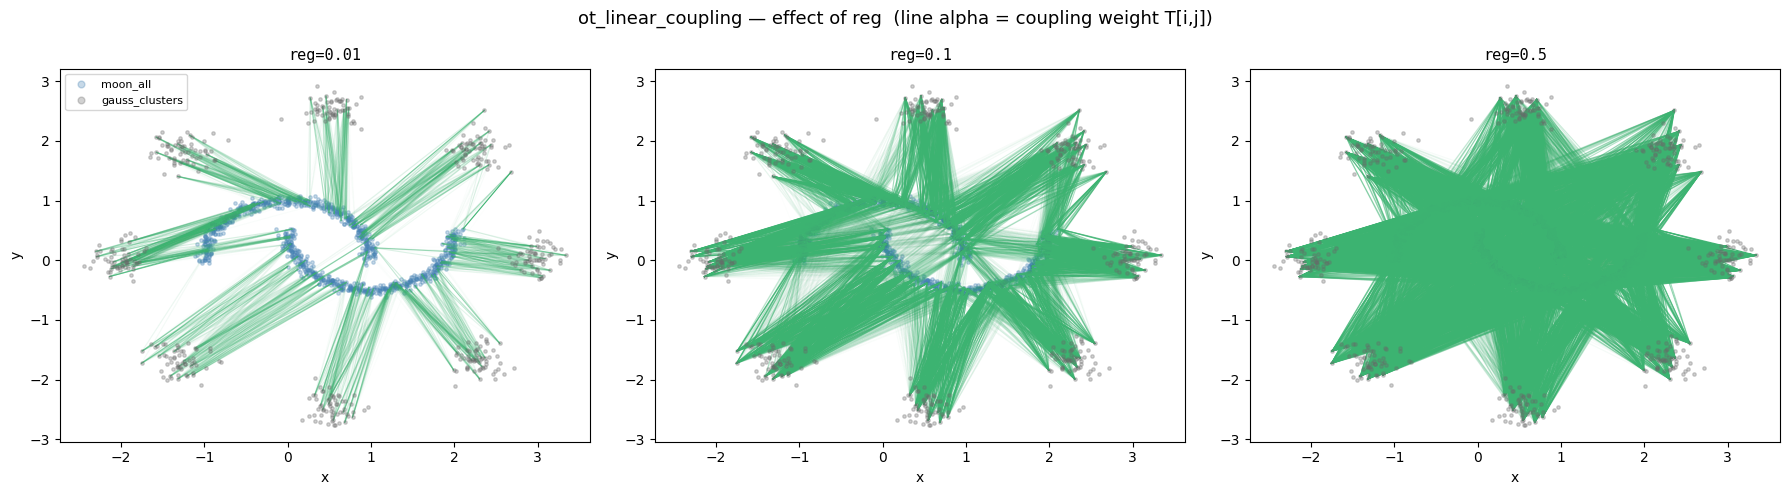

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, reg in zip(axes, regs, strict=False):
    tmat_norm = coupling_matrices_reg[reg] / coupling_matrices_reg[reg].max()
    for i in range(tmat_norm.shape[0]):
        for j in range(tmat_norm.shape[1]):
            alpha = float(tmat_norm[i, j])
            if alpha < 0.01:
                continue
            s = src[i].numpy()
            t = tgt[j].numpy()
            ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.8, alpha=alpha, color="mediumseagreen")
    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="moon_all")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="gauss_clusters"
    )
    ax.set_title(f"reg={reg}", fontsize=11, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes[0].legend(markerscale=2, fontsize=8)
plt.suptitle("ot_linear_coupling — effect of reg  (line alpha = coupling weight T[i,j])", fontsize=13)
plt.tight_layout()
plt.show()

### Effect of `method`

The `method` parameter selects the OT solver:

- **`"exact"`** — Earth Mover's Distance. No regularisation. Expensive on large batches.
- **`"sinkhorn"`** — Entropic regularisation (default). Plan regularized by `reg`. Faster and more stable.
- **`"partial"`** — Only a fraction `m` of total mass is transported.
- **`"unbalanced"`** — Marginals are relaxed by `reg_m`. Every source still participates, but points far from a match contribute less weight.

In [27]:
configs = [
    ("exact", {}),
    ("sinkhorn", {"reg": 0.1}),
    ("partial", {"reg": 0.1, "m": 0.7}),
    ("unbalanced", {"reg": 0.1, "reg_m": 0.5}),
]

coupling_results_method = [(method, kw, *ot_linear_coupling(src, tgt, method=method, **kw)) for method, kw in configs]

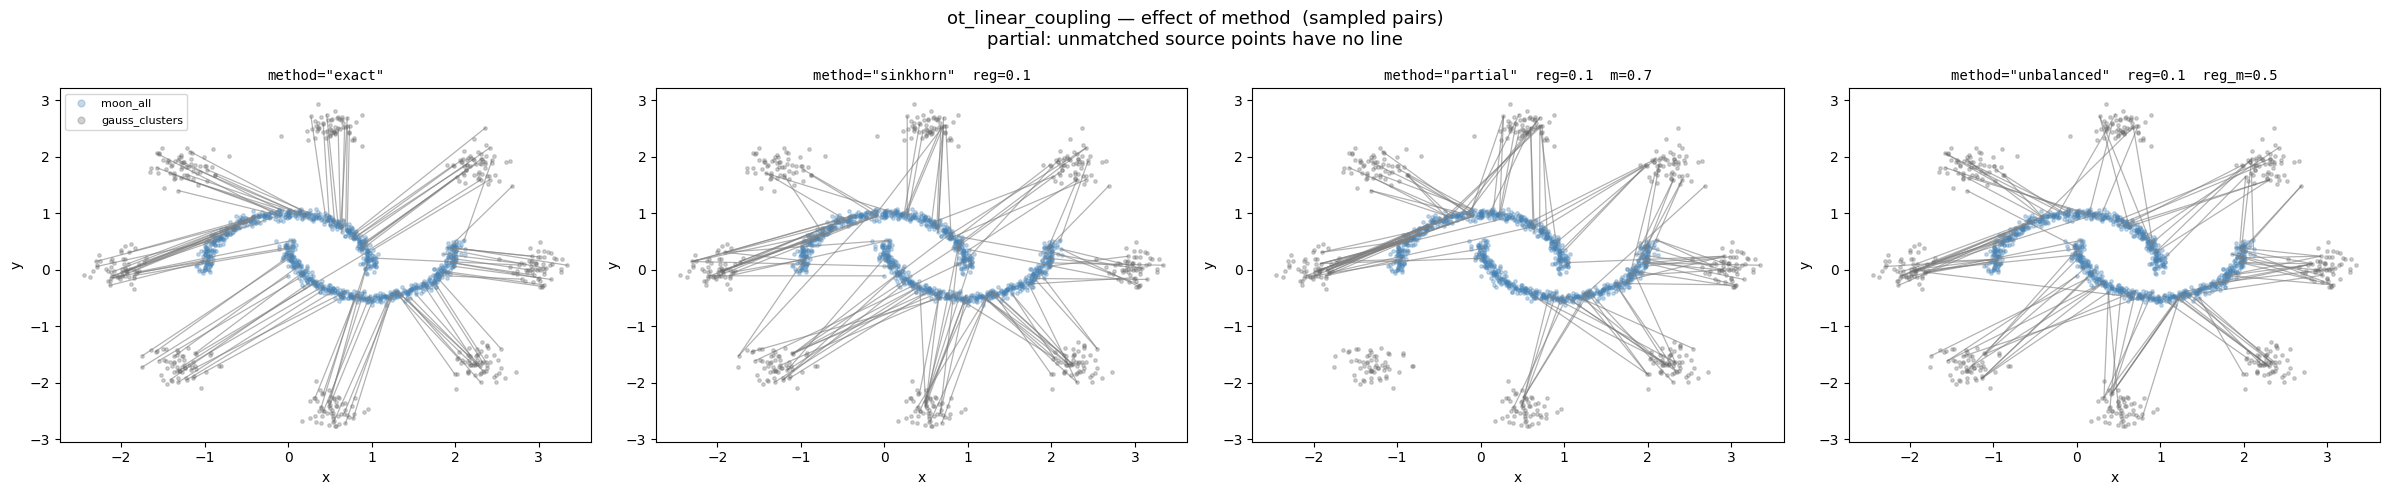

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (method, kw, src_idx, tgt_idx) in zip(axes, coupling_results_method, strict=False):
    for i in range(len(src_idx)):
        s = src[src_idx[i]].numpy()
        t = tgt[tgt_idx[i]].numpy()
        ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.9, alpha=0.6, color="gray")
    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="moon_all")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="gauss_clusters"
    )
    subtitle = f'method="{method}"'
    if kw:
        subtitle += "  " + "  ".join(f"{k}={v}" for k, v in kw.items())
    ax.set_title(subtitle, fontsize=10, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes[0].legend(markerscale=2, fontsize=8)
plt.suptitle(
    "ot_linear_coupling — effect of method  (sampled pairs)\npartial: unmatched source points have no line",
    fontsize=13,
)
plt.tight_layout()
plt.show()

---
## 3. Using Coupling with SCFlow

Coupling is passed to `SCFlow` via the `match_fn` parameter. SCFlow calls it internally at every training step — you never pass data yourself.

Both functions can be passed **directly** (uses their defaults):

```python
model = SCFlow(..., match_fn=independent_coupling)
model = SCFlow(..., match_fn=ot_linear_coupling)   # default reg=0.5
```

To override defaults like `reg`, use `functools.partial`. It does **not** call the function — it returns a new callable with the chosen kwargs pre-bound, which SCFlow then calls later with the batch data:

```python
from functools import partial

model = SCFlow(..., match_fn=partial(ot_linear_coupling, reg=0.1))
model = SCFlow(..., match_fn=partial(ot_linear_coupling, reg=0.1, method="exact"))
```

The default when `match_fn` is omitted is `independent_coupling`.

Below we train two models — one with each coupling — and compare the generated samples.

In [29]:
n_target = len(moon_all)
adata_target = ad.AnnData(
    X=moon_all.numpy(),
    obs=pd.DataFrame(index=[str(i) for i in range(n_target)]),
)
SCFlow.register_adata(adata_target)

np.random.seed(0)
n_noise = 500
adata_noise = ad.AnnData(
    X=np.random.randn(n_noise, 2).astype(np.float32),
    obs=pd.DataFrame(index=[str(i) for i in range(n_noise)]),
)

In [30]:
from functools import partial

coupling_configs = {
    "independent_coupling": independent_coupling,
    "ot_linear_coupling (reg=0.1)": partial(ot_linear_coupling, reg=0.1),
}

generated_scflow = {}
for name, match_fn in coupling_configs.items():
    torch.manual_seed(42)
    model = SCFlow(
        method_id="cfm",
        backend="torch",
        generate_from_noise=True,
        match_fn=match_fn,
        vf_decoder_mlp_kwargs={"hidden_dims": [64, 64]},
    )
    model.train(adata_target, n_train_steps=2_000, train_batch_size=256, optim_kwargs={"lr": 1e-3})
    adata_pred = model.predict(adata_noise, num_steps=20)
    generated_scflow[name] = np.array(adata_pred.X)
    print(f"  {name} done")

100%|██████████| 1/1 [00:00<00:00, 306.65it/s]
| loss:0.7887 | step:2000: 100%|██████████| 2000/2000 [00:14<00:00, 141.16it/s]
Predicting: 100%|██████████| 1/1 [00:12<00:00, 12.48s/it]


  independent_coupling done


100%|██████████| 1/1 [00:00<00:00, 1761.57it/s]
| loss:0.9266 | step:2000: 100%|██████████| 2000/2000 [00:10<00:00, 184.30it/s]
Predicting: 100%|██████████| 1/1 [00:00<00:00, 50.71it/s]

  ot_linear_coupling (reg=0.1) done


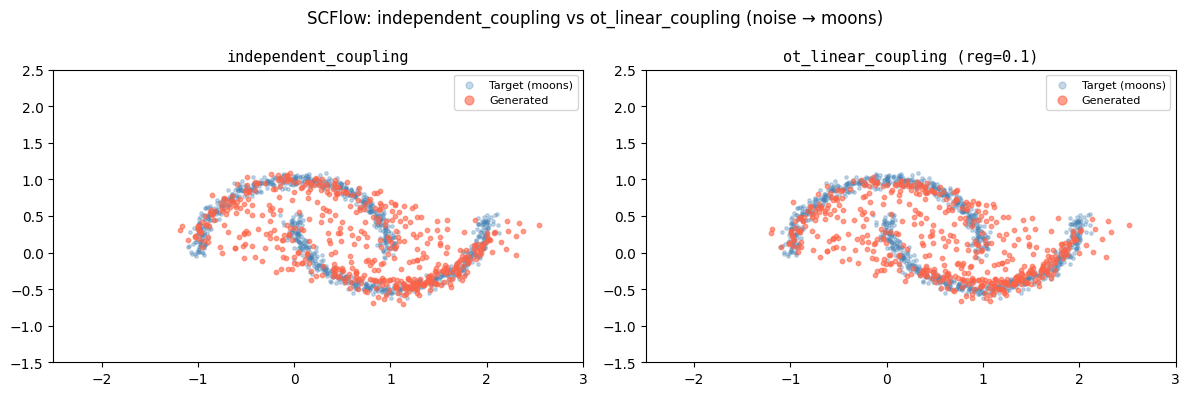

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pts) in zip(axes, generated_scflow.items(), strict=True):
    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, label="Target (moons)")
    ax.scatter(pts[:, 0], pts[:, 1], s=10, color="tomato", alpha=0.6, label="Generated")
    ax.set_title(name, fontsize=11, family="monospace")
    ax.set_xlim(-2.5, 3.0)
    ax.set_ylim(-1.5, 2.5)
    ax.legend(fontsize=8, markerscale=2)
plt.suptitle("SCFlow: independent_coupling vs ot_linear_coupling (noise → moons)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Writing a Custom Coupling

Any callable with this signature works as a `match_fn` in SCFlow:

```python
def my_coupling(
    source_lin,       # (N, D) source batch
    target_lin,       # (M, D) target batch
    source_quad=None, # optional — only needed for quadratic/GW transport
    target_quad=None, # optional — only needed for quadratic/GW transport
) -> tuple[np.ndarray, np.ndarray]:  # (src_idx, tgt_idx)
    ...
```

SCFlow calls it with **keyword arguments** at every training step and uses the returned index arrays to reorder the batch before fitting the velocity field:

```python
model = SCFlow(..., match_fn=my_coupling)
```

For a biological example using a spatially-aware custom coupling (CTF-C from ContextFlow) on real Stereo-seq data, see [Tutorial 400](../../tutorials/400_contextflow_axolotl.ipynb).

### 4.1 Nearest-Neighbour Coupling

The simplest non-trivial custom coupling: match each source point to its nearest target point in the batch.

Unlike OT, no transport plan is solved — the assignment is greedy and deterministic. This makes it cheap but suboptimal: the same target point can be picked by multiple sources, and distant outliers are always matched to whichever target happens to be closest.

In [ ]:
def nn_coupling(source_lin, target_lin, source_quad=None, target_quad=None):
    """Match each source point to its nearest target point."""
    dists = torch.cdist(source_lin, target_lin)  # (N, M) pairwise distances
    tgt_idx = dists.argmin(dim=1).numpy()  # greedy nearest neighbour
    src_idx = np.arange(len(source_lin))
    return src_idx, tgt_idx


src_idx_nn, tgt_idx_nn = nn_coupling(src, tgt)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pairs(axes[0], src, tgt, src_idx, tgt_idx, title="ot_linear_coupling  (min-cost plan)")
plot_pairs(axes[1], src, tgt, src_idx_nn, tgt_idx_nn, title="nn_coupling  (greedy nearest neighbour)")
for ax in axes:
    ax.legend(markerscale=2, fontsize=8)
plt.suptitle("Custom coupling: greedy nearest-neighbour vs optimal transport", fontsize=12)
plt.tight_layout()
plt.show()